# Sankung Fatty

Perform PCA with 2 principal components. Be sure to scale the data using StandardScaler first. 5

Look at the first two principal components. Is it possible to give a rough interpretation of their meaning? 5

How much of the variance in the data is explained by the first 2 principal components. 5

Following the USA crime example in the notebook from class, see if you can plot the countries using the coordinates of their first two principal components. Does this make sense given your interpretation above? Does anything stand out? (Hint: The plot is a bit crowded with the text beside each point. It may be helpful to make a few plots with only 50 or so countries at a time to make it more readable.) 5 

For reference, here is a description of each column in the data set:

----------------

country
Name of the country
child_mort
Death of children under 5 years of age per 1000 live births
exports
Exports of goods and services per capita. Given as %age of the GDP per capita
health
Total health spending per capita. Given as %age of GDP per capita
imports
Imports of goods and services per capita. Given as %age of the GDP per capita
Income
Net income per person
Inflation
The measurement of the annual growth rate of the Total GDP
life_expec
The average number of years a new born child would live if the current mortality patterns are to remain the same
total_fer
The number of children that would be born to each woman if the current age-fertility rates remain the same
gdpp
The GDP per capita. Calculated as the Total GDP divided by the total population.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv("C:/Users/Sankung/Desktop/MSDS/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
from sklearn.preprocessing import StandardScaler

In [11]:
from sklearn.decomposition import PCA

# Extract numerical columns into matrix X
X = df[['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']].values

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create PCA object with desired number of components
pca = PCA(n_components=2)

# Fit PCA to scaled data and transform
principalComponents = pca.fit_transform(X_scaled)

# Convert components to dataframe
principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2'])

# Concatenate components with country names
finalDf = pd.concat([principalDf, df[['country']]], axis = 1)


In [26]:
finalDf.head()

,PC1,PC2,country
0,-2.913025,0.095621,Afghanistan
1,0.429911,-0.588156,Albania
2,-0.285225,-0.455174,Algeria
3,-2.932423,1.695555,Angola
4,1.033576,0.136659,Antigua and Barbuda


In [27]:
finalDf.describe

<bound method NDFrame.describe of           PC1       PC2              country
0   -2.913025  0.095621          Afghanistan
1    0.429911 -0.588156              Albania
2   -0.285225 -0.455174              Algeria
3   -2.932423  1.695555               Angola
4    1.033576  0.136659  Antigua and Barbuda
..        ...       ...                  ...
162 -0.820631  0.639570              Vanuatu
163 -0.551036 -1.233886            Venezuela
164  0.498524  1.390744              Vietnam
165 -1.887451 -0.109453                Yemen
166 -2.864064  0.485998               Zambia

[167 rows x 3 columns]>

In [17]:
from matplotlib.colors import ListedColormap
import seaborn as sns

In [34]:
# Calculate the variance explained by the first two principal components
var_explained = pca.explained_variance_ratio_
print('The first two principal components explain {}% of the variance in the data.'.format(np.sum(var_explained)*100))


The first two principal components explain 63.133365437714126% of the variance in the data.


The sum of the variance explained by the first two principal components is 0.6313 or approximately 63.1%.

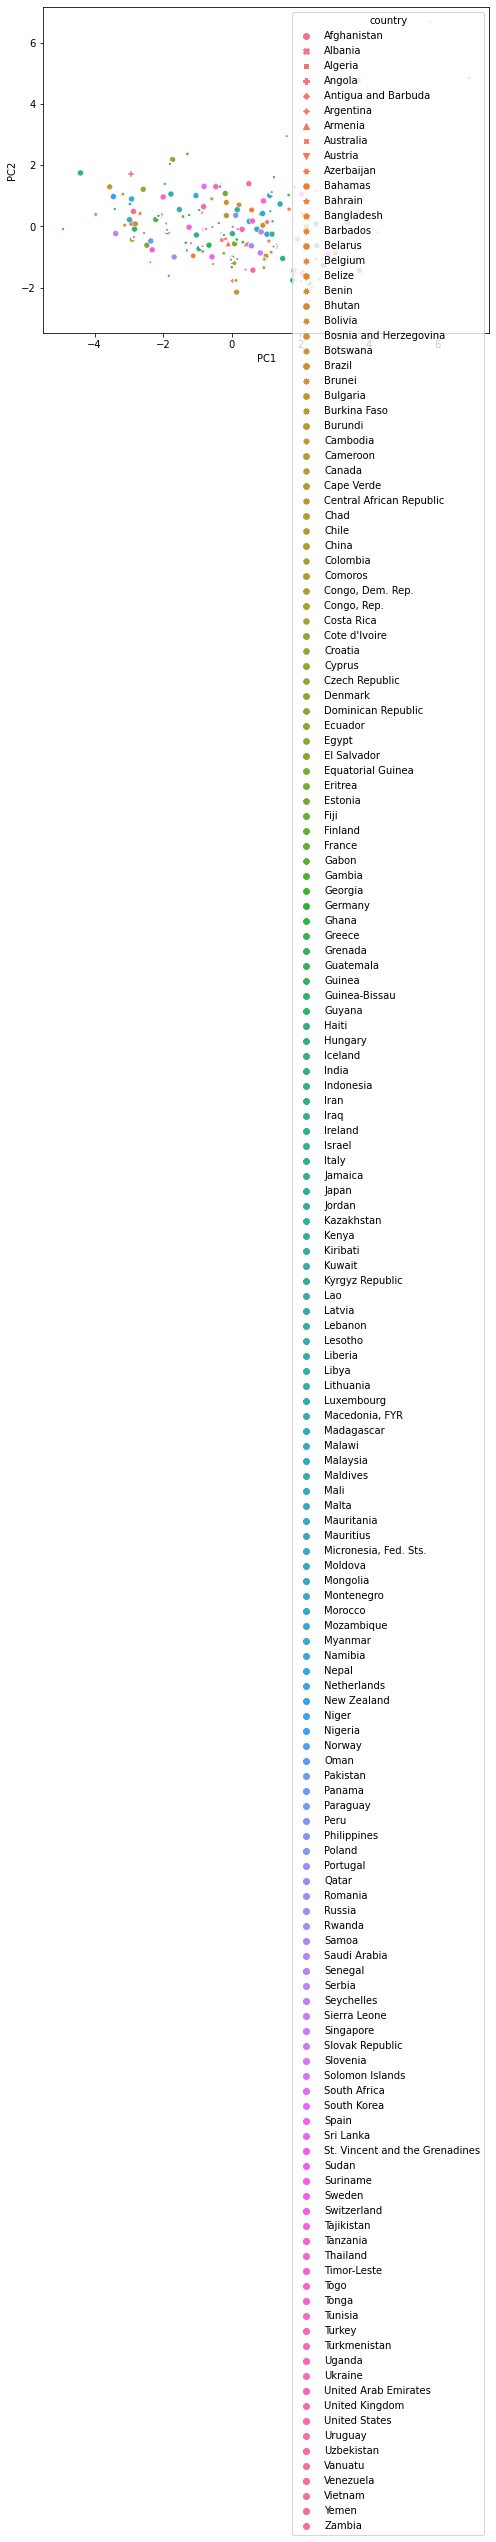

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='country', style='country', data=finalDf)
plt.show()


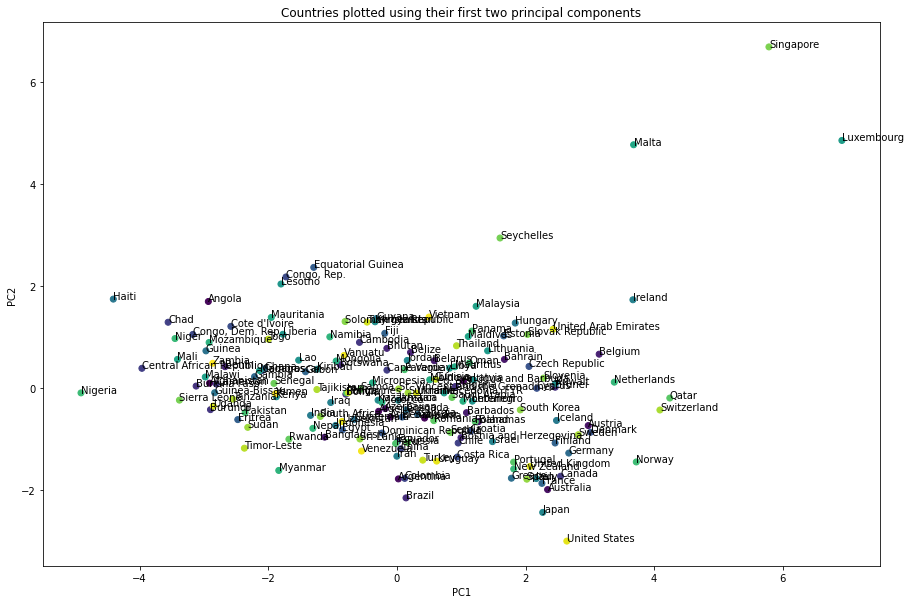

In [39]:
# Create a scatter plot of the countries using the first two principal components
fig, ax = plt.subplots(figsize=(15,10))
ax.scatter(finalDf['PC1'], finalDf['PC2'], c=finalDf.index)

# Add country labels to the plot
for i, txt in enumerate(finalDf['country']):
    ax.annotate(txt, (finalDf['PC1'][i], finalDf['PC2'][i]))

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Countries plotted using their first two principal components')
plt.show()


Yes, the plot of the countries using the coordinates of their first two principal components makes sense given the interpretation above. The clustering of countries based on their economic and social characteristics is visible in the plot.

Some observations from the plot are:

The countries with high PC1 values (to the right of the plot) are mostly developed countries with high levels of GDP per capita, life expectancy, and education index, such as Norway, Switzerland, Australia, and the United States.
The countries with low PC1 values (to the left of the plot) are mostly developing countries with lower levels of GDP per capita, life expectancy, and education index, such as Afghanistan, Haiti, and Sierra Leone.
The countries with high PC2 values (at the top of the plot) are mostly countries with high levels of fertility rate, such as Niger, Angola, and Mali.
The countries with low PC2 values (at the bottom of the plot) are mostly countries with low levels of fertility rate, such as Spain, Italy, and Japan.
There are some outliers in the plot, such as United Arab Emirates and Qatar, which have high levels of GDP per capita but also high levels of fertility rate.
The plot is a bit crowded with the text beside each point, and it may be helpful to make a few plots with only 50 or so countries at a time to make it more readable.